# Tableau Blending
- Data blending in Tableau allows you to combine data from multiple independent data sources directly within a single worksheet.
- Unlike joins or relationships which combine data before aggregation, blending queries each data source separately, aggregates the data to a common level, and then visually blends the results together (similar to a Left Join
- https://help.tableau.com/current/pro/desktop/en-us/multiple_connections.htm

## Links
- https://help.tableau.com/current/pro/desktop/en-us/multiple_connections.htm
- https://youtu.be/xFyjOd2lMO8

## Options to combine data
- There are several ways to combine data, each with their own strengths and weaknesses.
- Relationships are the default method and can be used in most instances, including across tables with different levels of detail. Relationships are flexible and adapt to the structure of the analysis on a sheet by sheet basis. Relationships are the best option to combine published data sources.
- Joins combine tables by adding more columns of data across similar row structures. This can cause data loss or duplication if tables are at different levels of detail, and joins must be established before analysis can begin. You can't use a published data source in a join.
- Blends, unlike relationships or joins, never combine the data directly. Instead, blends query each data source independently, aggregate the results to the appropriate level, then present the results together visually in the view. Blends don't create a new, blended data source (and therefore can't be published as a "blended data source"). Instead, they are simply blended results visualized per sheet.


## Steps for blending data
- Data blending is performed on a sheet-by-sheet basis and is established when a field from a second data source is used in the view.
- To create a blend in a workbook, you need to connect to at least two data sources. Then bring a field from one data source to the sheet—it becomes the primary data source. Switch to the other data source and use a field on the same sheet—it becomes a secondary data source. A linking icon will appear in the data pane, indicating which field(s) are being used to blend the data sources.
    - Ensure that the workbook has multiple data sources. The second data source should be added by going to Data > New data source.
Tip: Blending requires two or more distinct data sources, listed independently in the Data pane. Adding another connection to the first data source enables relationships and joins on the Data Source page.
    - Drag a field to the view. This data source will be the primary data source.
    - Switch to another data source and verify there is a blend relationship to the primary data source.
        - If there is a linking field icon (Blending link icon.), the data sources are automatically linked. As long as there is at least one active link, the data can be blended.
        - If there are broken link icons (Blending link broken icon.), click the icon next to the field that should link the two data sources. The slash will go away, representing an active link.
        - If a link icon does not appear next to the desired field, see Define blend relationships for blending.
    - Drag a field into the view from the secondary data source.
- As soon as this second data source is used in the same view, a blend is established. In the example below, our primary data source is Movie Adaptations and the secondary data source is Bookshop.
- The primary data source is indicated with a blue check mark on the data source. Fields from the primary data source used in the view have no indication.
- The secondary data source is indicated with an orange check mark on the data source and an orange bar down the side of the Data pane. Fields from the secondary data source used in the view have an orange check mark.

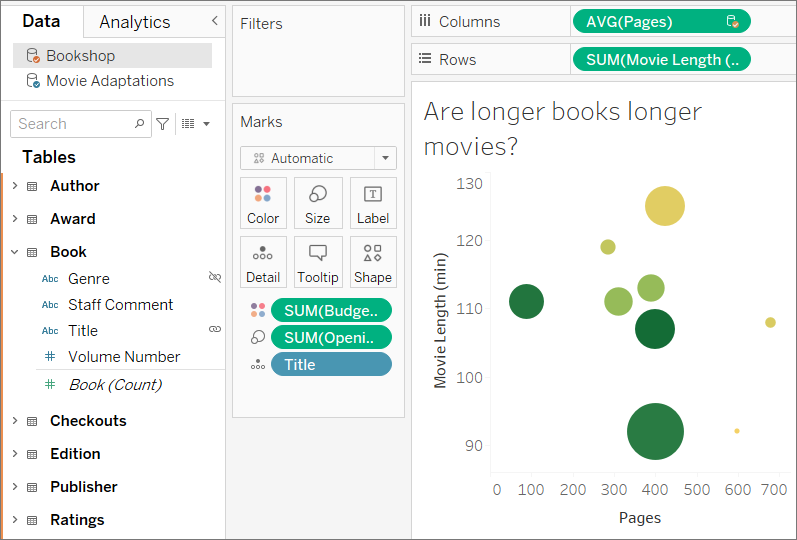

## Data
- Bookshop https://help.tableau.com/current/pro/desktop/en-us/bookshop_data.htm

# Blending in Python

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
sheet_id = "1OzAar2RPWjJ9OgvS0h3Fpj7JjsJ2TOijB623-SyM1DU"
gid1 ='1124164429'
gid2 ='1481659858'
url1 = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid1}"
url2 = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid2}"
print(url1, '\n', url1)

In [14]:
sales = pd.read_csv(url1)
print(sales.head())
print(sales.shape)

  orderID   orderDate   region  sales
0  TX-001  2026-01-15     East    500
1  TX-002  2026-01-16     East    350
2  TX-003  2026-01-17     West    700
3  TX-004  2026-01-18  Central    400
4  TX-005  2026-01-19     West    150
(5, 4)


In [15]:
target = pd.read_csv(url2)
print(target.head())
print(target.shape)

      area  target
0     East    1000
1     West    1200
2  Central     800
(3, 2)


In [16]:
# group sales by region
salesSum = sales.groupby('region')['sales'].sum().reset_index()
salesSum

,region,sales
0,Central,400
1,East,850
2,West,850


In [19]:
blend1 =  pd.merge(salesSum, target, left_on='region', right_on='area', how='inner')
blend1

,region,sales,area,target
0,Central,400,Central,800
1,East,850,East,1000
2,West,850,West,1200


In [20]:
blend1

,region,sales,area,target
0,Central,400,Central,800
1,East,850,East,1000
2,West,850,West,1200
